In [1]:
import numpy as np

folder_name='/home/malavolta/data/ExoAtmospheres/HD189733/'
mask = 'G2'
output_name = 'ccf_rmr_HARPS_G2_prefit'

# The following values must be gathered from the RV + transit fit 
observations_dict = {
    '2007-07-19': {
        'mask': 'G2',
        'write_rvfile': True,
        'rv_model': {
            'analytical_model': True,
            'fitted_model': '.dat'
        },
    },
    '2007-08-28':  {
        'mask': 'G2',
        'write_rvfile': True,
        'rv_model': {
            'analytical_model': True,
            'fitted_model': '.dat'
        },
    },
    #'2007-07-19':  {
    #    'mask': 'K5',
    #    'rv_model': {
    #        'analytical_model': False, # specify if an alytical model must be computed, or if the RV+RM fit is available 
    #        'fitted_model': '.dat' #File where the full model and the RML model are stored
    #    },
    #},
    #'2007-08-28':  {
    #    'mask': 'K5',
    #    'rv_model': {
    #        'analytical_model': False,
    #        'fitted_model': '.dat'
    #    },
    #},
}

planet_dict = {
    'period': 2.21857567,  # days
    'RV_semiamplitude': 0.20056, #km/s
    'Tc': 2454279.436714, # reference central time of transit, in BJD_TDB 
    'T14': 1.827/24., # total duration of the transit, in days
    'bjd_offset': 0.000
}


In [2]:

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})

import pickle #this is a very useful module indeed !
from numpy.polynomial import Polynomial

import os 
from astropy.io import fits
import sys
sys.path.insert(0, '../subroutines/')
from mu_vstar import compute_mu_vstar_grid
from rebin import *

import batman

%matplotlib notebook 

from scipy.optimize import curve_fit


In [3]:
#Define the Gaussian function
def CCF_gauss(x, rv, contrast, fwhm):
    sigma = fwhm /( 2 * np.sqrt(2*np.log(2)))
    return 1. - contrast * np.exp(-(x - rv) ** 2 / (2 * sigma ** 2))
#Define the Gaussian function
def CCF_gauss_continuum(x, rv, contrast, fwhm, continuum):
    sigma = fwhm /( 2 * np.sqrt(2*np.log(2)))
    return continuum*(1. - contrast * np.exp(-(x - rv) ** 2 / (2 * sigma ** 2)))

In [4]:
#Here I define the function to get the ccf

def ccf_finder(folder_name, night, mask):
    
    ccf_name = 'ccf_' + mask + '_A'
    d=os.listdir(folder_name+'/'+night)
    sub_ccf = []
    for j in d:
        if ccf_name in j:
            sub_ccf.append(j) 
    return sub_ccf



In [5]:
from astropy.coordinates import SkyCoord, EarthLocation
from astropy import units as u
from astropy.time import Time
def bjd_utc_to_tdb(utc):
    utc_astropy = Time(utc, scale='utc', format='jd')
    return utc_astropy.tdb.to_value('jd') 

In [6]:
#this is a function to find T1 and T4 of the night we are considering

#NOTE: T1_ext and T4_ext are enlarged with respect to the actual values resulting from the ephemeris
# so that a slighlty wrong values for the transit time and the period 
# so that our MCMC fit will not be sensitive to the exact choice of the CCFs

def t_lim(tm, planet_dict): #it takes the mean value of all the times of observation as input
    N=np.rint((planet_dict['Tc']-tm)/planet_dict['period']) #number of complete orbits
    T0 = planet_dict['Tc']-N*planet_dict['period'] #midtransit time of the night 
    T1=T0-(0.5*planet_dict['T14']) #time of ingress
    T4=T0+(0.5*planet_dict['T14']) #time of egress
    T1_ext=T0-(0.6*planet_dict['T14']) #time of ingress
    T4_ext=T0+(0.6*planet_dict['T14']) #time of egress
    return T1,T4,N,T0, T1_ext, T4_ext

def create_symmetric_array(limit, diff):
    lst = np.arange(diff, limit, diff)
    if (lst[-1] != limit):
        lst = np.r_[lst, limit]
         
    return np.r_[-lst[::-1], 0, lst]

In [7]:
ccf_common_x = None
fwhm_criterion = None

n_intransit = 0
n_intransit_ext = 0

from IPython.display import display, Math

for night, night_dict in observations_dict.items():

    ccf_files = ccf_finder(folder_name, night, night_dict['mask'])

    n = len(ccf_files)
    ccf_length = 161
    
    night_dict['n_obs'] = n
    night_dict['bjd_utc'] = np.zeros(n, dtype=np.double)
    night_dict['rvc'] = np.zeros(n, dtype=np.double)
    night_dict['rv_noise'] = np.zeros(n, dtype=np.double)
    night_dict['fwhm'] = np.zeros(n, dtype=np.double)
    night_dict['exptime'] = np.zeros(n, dtype=np.double)
    night_dict['ccf_drs_x'] = np.zeros((n, ccf_length), dtype=np.double) 
    night_dict['ccf_drs_s'] = np.zeros((n, ccf_length), dtype=np.double) 
    night_dict['ccf_drs_y'] = np.zeros((n, ccf_length), dtype=np.double) 

    
    for i_file, filename in enumerate(ccf_files):
        hdu_list=fits.open(folder_name+'/'+night+'/'+filename)

        night_dict['bjd_utc'][i_file] = hdu_list[0].header["HIERARCH ESO DRS BJD"] - planet_dict['bjd_offset'] # time in BJD_UTC ?
        
        night_dict['fwhm'][i_file] = hdu_list[0].header["HIERARCH ESO DRS CCF FWHM"] #FWHM of CCF (km/s)
        night_dict['rvc'][i_file] = hdu_list[0].header["HIERARCH ESO DRS CCF RVC"] #the Baryc RV (drift corrected) (km/s)
        night_dict['rv_noise'][i_file] = hdu_list[0].header["HIERARCH ESO DRS CCF NOISE"] #
        night_dict['exptime'][i_file] = hdu_list[0].header["EXPTIME"] #Total integration time s        
        crval = hdu_list[0].header["CRVAL1"]
        cdelt = hdu_list[0].header["CDELT1"]
        night_dict['ccf_drs_x'][i_file, :] = crval + np.arange(0, ccf_length, 1.)*cdelt
        night_dict['ccf_drs_s'][i_file, :] = cdelt
        night_dict['ccf_drs_y'][i_file, :] = hdu_list[0].data[-1,:]
    

    night_dict['bjd'] = bjd_utc_to_tdb(night_dict['bjd_utc'])
        
    night_dict['average_bjd'] = np.average(night_dict['bjd'])
    
    #fileout = open('RVfile_'+night+'_PyORBIT.dat', 'w')
    #fileout.write('# epoch value error jitter offset subset exptime \n')
    #for b,r,er, ex in zip(night_dict['bjd'], night_dict['rvc']*1000, night_dict['rv_noise']*1000, night_dict['exptime']):
    #    fileout.write('{0:16f} {1:12f} {2:12f} 0 0 -1 {3:12f} \n'.format(b,r,er,ex))
    #fileout.close()
    
    T1,T4,N,T0, T1_ext, T4_ext = t_lim(night_dict['average_bjd'], planet_dict)
    night_dict['transit_T1'] = T1
    night_dict['transit_T4'] = T4
    night_dict['transit_N'] = N
    night_dict['transit_T0'] = T0        
    night_dict['transit_T1_ext'] = T1_ext
    night_dict['transit_T4_ext'] = T4_ext    
    
    night_dict['in_transit'] = \
           (night_dict['bjd'] >= night_dict['transit_T1']) \
         & (night_dict['bjd'] <= night_dict['transit_T4'])
    night_dict['out_transit'] = ~night_dict['in_transit']
    
    night_dict['in_transit_ext'] = \
           (night_dict['bjd'] >= night_dict['transit_T1_ext']) \
         & (night_dict['bjd'] <= night_dict['transit_T4_ext'])
    night_dict['out_transit_ext'] = ~night_dict['in_transit_ext']    
    
    
    if night_dict['rv_model']['analytical_model']:
        rv_planet = -planet_dict['RV_semiamplitude']*np.sin(2*np.pi*(night_dict['bjd']-night_dict['transit_T0'])/planet_dict['period'])
        rm_anomaly = night_dict['rvc'] - rv_planet
        gamma = np.average(rm_anomaly[night_dict['out_transit_ext']])
        night_dict['rv_star'] = rv_planet + gamma
    else:
        print('NOT IMPLEMENTED, error')

    night_dict['planet_orbital_phase'] = (night_dict['bjd']-night_dict['transit_T0'])/planet_dict['period']

    step = 0.25 
    if ccf_common_x is None:
        n_side = (len(night_dict['ccf_drs_x'][0,:]) - 8 - 1)/2
        ccf_common_x = create_symmetric_array(n_side*step, step)
        
    night_dict['ccf_common_x'] = ccf_common_x
        
    night_dict['ccf_x'] = np.zeros((night_dict['n_obs'], len(night_dict['ccf_common_x'])), dtype=np.double)
    night_dict['ccf_s'] = np.ones_like(night_dict['ccf_x']) * step
    night_dict['ccf_y'] = np.zeros_like(night_dict['ccf_x'])
    
    
    for i in range(night_dict['n_obs']):
        night_dict['ccf_x'][i,:] = night_dict['ccf_common_x']
        night_dict['ccf_y'][i,:] = rebin_ccf(
            night_dict['ccf_drs_x'][i,:],
            night_dict['ccf_drs_s'][i,:],
            night_dict['ccf_drs_y'][i,:],
            night_dict['ccf_x'][i,:],
            night_dict['ccf_s'][i,:],
            rv_shift=-night_dict['rv_star'][i],
            preserve_flux=False
        )

    night_dict['ccf_master_out'] = np.sum(night_dict['ccf_y'][night_dict['out_transit_ext']], axis=0)

    parameters, covariance = curve_fit(CCF_gauss,
                                   night_dict['ccf_common_x'],
                                   night_dict['ccf_master_out']/np.amax(night_dict['ccf_master_out']))
    print('RV of CCF master out: ', parameters[0])
    print('Contrast of CCF master out: ', parameters[1])
    print('FWHM of CCF master out: ', parameters[2])
    
    
    if fwhm_criterion is None:
        fwhm_criterion = np.average(night_dict['fwhm'])*1.5 
    night_dict['continuum_selection'] = (np.abs(night_dict['ccf_common_x']) > fwhm_criterion)
    
    poly = Polynomial.fit(night_dict['ccf_common_x'][night_dict['continuum_selection']],
               night_dict['ccf_master_out'][night_dict['continuum_selection']],
               2)
    night_dict['ccf_normal_out'] = night_dict['ccf_master_out']/poly(night_dict['ccf_common_x'])

    night_dict['ccf_normal_y'] = np.zeros_like(night_dict['ccf_x'])
    night_dict['ccf_normal_e'] = np.zeros_like(night_dict['ccf_x'])
    
    
    n_intransit += np.sum(night_dict['in_transit']) 
    n_intransit_ext += np.sum(night_dict['in_transit_ext']) 
    

    for i in range(night_dict['n_obs']):

        poly = Polynomial.fit(night_dict['ccf_x'][i,night_dict['continuum_selection']],
                   night_dict['ccf_y'][i,night_dict['continuum_selection']],
                   2)
        night_dict['ccf_normal_y'][i,:] = night_dict['ccf_y'][i,:]/poly(night_dict['ccf_x'][i,:])
    
        #night_dict['ccf_normal_e'][i,:] = np.std(night_dict['ccf_normal_y'][i,night_dict['continuum_selection']])
        ccf_difference= night_dict['ccf_normal_y'][i,:]-night_dict['ccf_normal_out']
        night_dict['ccf_normal_e'][i,:] = np.std(ccf_difference[night_dict['continuum_selection']])

    
    params = batman.TransitParams() #object to store transit parameters
    params.t0 = night_dict['transit_T0'] #time of inferior conjunction in days # here I have to set the "right one"
    params.per = 2.21857567 #± 0.00000015 #orbital period in days
    params.rp = 0.15667 #± 0.00012 Rstar  #planet radius (in units of stellar radii)
    params.a = 8.863 #± 0.020 #semi-major axis (in units of stellar radii)
    params.inc = 85.710 #± 0.024° #orbital inclination (in degrees)
    params.ecc = 0.#eccentricity
    params.w = 90.#longitude of periastron (in degrees)
    params.limb_dark = "quadratic" #limb darkening model
    params.u = [0.816,0] #limb darkening coefficients [u1, u2]

    t =night_dict['bjd'] #times at which to calculate light curve in transit
    mod = batman.TransitModel(params, t) #initializes model in transit
    flux = mod.light_curve(params) #calculates light curve in transit
    night_dict['batman_flux'] = flux
    
    ccf_normal_out_2d, batman_flux_2d = np.meshgrid(night_dict['ccf_normal_out'], night_dict['batman_flux'])
    ccf_common_x_2d, orbital_phase_2d = np.meshgrid(night_dict['ccf_common_x'], night_dict['planet_orbital_phase'])

    residuals_matrix =  (ccf_normal_out_2d - night_dict['ccf_normal_y']*batman_flux_2d) / (1. - batman_flux_2d)
    mask = ~np.isfinite(residuals_matrix)
    residuals_matrix[mask] = 1.
    residuals_errors =  (night_dict['ccf_normal_e']*batman_flux_2d) / (1. - batman_flux_2d)
    residuals_errors[mask] = 10.
    mask = ~np.isfinite(residuals_errors)
    residuals_errors[mask] = 10.
    
    night_dict['ccf_rescaled_y'] = residuals_matrix
    night_dict['ccf_rescaled_e'] = residuals_errors

    """ 
    plt.figure(figsize=(8,8))
    for i in range(night_dict['n_obs']):
        if night_dict['in_transit'][i]: 
            plt.plot(night_dict['ccf_x'][i,:],residuals_matrix[i,:])
    
    plt.ylim(0.2, 1.2)
    plt.title("Residuals master oot CCFs - itr CCFs")
    plt.xlabel("RV[km/s]") 
    plt.ylabel("Residual flux")
    plt.show()
    
    plt.figure(figsize=(8,8))
    for i in range(night_dict['n_obs']):
        if night_dict['in_transit'][i]: 
            plt.plot(night_dict['ccf_x'][i,:],residuals_errors[i,:])
            print(residuals_errors[i,:])
    plt.ylim(0.2, 1.2)
    plt.title("Residuals master oot CCFs - itr CCFs")
    plt.xlabel("RV[km/s]") 
    plt.ylabel("Residual flux")
    plt.show()
    
    """
    
    
    """
    model_matrix = 1 - 0.4*np.exp(-(orbital_phase_2d*175-ccf_common_x_2d)**2 / (2*3)) 
    model_matrix[night_dict['out_transit'],:] = 0.0
    #residuals_matrix =  (ccf_normal_out_2d - night_dict['ccf_normal_y']*batman_flux_2d) / (1. - batman_flux_2d)
    
    compare_normal_y = (ccf_normal_out_2d - model_matrix * (1. - batman_flux_2d))/batman_flux_2d  
    # night_dict['ccf_normal_y']
    
    plt.figure(figsize=(6,5))
    ax = plt.gca()
    im = plt.imshow(night_dict['ccf_normal_y']-compare_normal_y,
                    cmap="hot_r",
                    extent=[night_dict['ccf_x'][0,0],night_dict['ccf_x'][0,-1],night_dict['planet_orbital_phase'][0],night_dict['planet_orbital_phase'][-1]],
                    vmin=-0.01, vmax=0.01,
                    origin='lower',
                   aspect='auto')
    plt.xlabel("RV [km/s]")
    plt.ylabel("Phase")
    ax.set_xlim(-10,10)
    ax.set_ylim(-0.02,0.02)
    plt.colorbar(im,label="Residual flux")
    plt.show()
    
    """
    
    
    #residuals_matrix =  (ccf_normal_out_2d - night_dict['ccf_normal_y']*batman_flux_2d) / (1. - batman_flux_2d)


RV of CCF master out:  -0.00011492913041839217
Contrast of CCF master out:  0.5029466890041097
FWHM of CCF master out:  7.840308634918766


/tmp/ipykernel_16411/1772301828.py:164: RuntimeWarning: divide by zero encountered in divide
  residuals_matrix =  (ccf_normal_out_2d - night_dict['ccf_normal_y']*batman_flux_2d) / (1. - batman_flux_2d)
/tmp/ipykernel_16411/1772301828.py:167: RuntimeWarning: divide by zero encountered in divide
  residuals_errors =  (night_dict['ccf_normal_e']*batman_flux_2d) / (1. - batman_flux_2d)


RV of CCF master out:  -4.549532406351873e-05
Contrast of CCF master out:  0.5012593294380528
FWHM of CCF master out:  7.8786619312980815


In [8]:
saved_files = {}

n_x = len(ccf_common_x)
n_y = n_intransit_ext

saved_files['data'] = np.zeros((n_y, n_x), dtype=np.double)
saved_files['errs'] = np.zeros((n_y, n_x), dtype=np.double)
saved_files['ccf_master'] = np.zeros((n_y, n_x), dtype=np.double)
saved_files['bjd'] = np.zeros(n_y, dtype=np.double)
saved_files['exptime'] = np.zeros(n_y, dtype=np.double)

saved_files['2nd_axis'] = ccf_common_x

n_start = 0
for night, night_dict in observations_dict.items():
    
    n_end = n_start + np.sum(night_dict['in_transit_ext'])

    ccf_normal_out_2d, bjd_2d = np.meshgrid(night_dict['ccf_normal_out'], night_dict['bjd'][night_dict['in_transit_ext']])

    saved_files['data'][n_start:n_end, :] =  night_dict['ccf_normal_y'][night_dict['in_transit_ext'],:]
    saved_files['errs'][n_start:n_end, :] =  night_dict['ccf_normal_e'][night_dict['in_transit_ext'],:]
    saved_files['ccf_master'][n_start:n_end, :] =  ccf_normal_out_2d
    saved_files['bjd'][n_start:n_end] =  night_dict['bjd'][night_dict['in_transit_ext']]
    saved_files['exptime'][n_start:n_end] =  night_dict['exptime'][night_dict['in_transit_ext']]

    n_start += np.sum(night_dict['in_transit_ext'])

    saved_night = {}
    saved_night['2nd_axis'] = ccf_common_x
    saved_night['data'] =  night_dict['ccf_normal_y'][night_dict['in_transit_ext'],:]
    saved_night['errs'] =  night_dict['ccf_normal_e'][night_dict['in_transit_ext'],:]
    saved_night['ccf_master'] =  ccf_normal_out_2d
    saved_night['bjd'] =  night_dict['bjd'][night_dict['in_transit_ext']]
    saved_night['exptime'] =  night_dict['exptime'][night_dict['in_transit_ext']]

    saved_night['jitter'] = 0
    saved_night['offset'] = -1
    saved_night['subset'] = -1
    
    with open(output_name+'_'+night+'_improved.pkl', 'wb') as file:
        pickle.dump(saved_night, file)
    
    
saved_files['jitter'] = 0
saved_files['offset'] = -1
saved_files['subset'] = -1

with open(output_name+'_improved.pkl', 'wb') as file:
    pickle.dump(saved_files, file)


In [9]:
saved_files = {}

n_x = len(ccf_common_x)
n_y = n_intransit

saved_files['data'] = np.zeros((n_y, n_x), dtype=np.double)
saved_files['errs'] = np.zeros((n_y, n_x), dtype=np.double)
saved_files['ccf_master'] = np.zeros((n_y, n_x), dtype=np.double)
saved_files['bjd'] = np.zeros(n_y, dtype=np.double)
saved_files['exptime'] = np.zeros(n_y, dtype=np.double)

saved_files['2nd_axis'] = ccf_common_x

n_start = 0
for night, night_dict in observations_dict.items():
    
    n_end = n_start + np.sum(night_dict['in_transit'])

    ccf_normal_out_2d, bjd_2d = np.meshgrid(night_dict['ccf_normal_out'], night_dict['bjd'][night_dict['in_transit']])

    saved_files['data'][n_start:n_end, :] =  night_dict['ccf_rescaled_y'][night_dict['in_transit'],:]
    saved_files['errs'][n_start:n_end, :] =  night_dict['ccf_rescaled_e'][night_dict['in_transit'],:]
    saved_files['ccf_master'][n_start:n_end, :] =  ccf_normal_out_2d
    saved_files['bjd'][n_start:n_end] =  night_dict['bjd'][night_dict['in_transit']]
    saved_files['exptime'][n_start:n_end] =  night_dict['exptime'][night_dict['in_transit']]

    n_start += np.sum(night_dict['in_transit'])

    saved_night = {}
    saved_night['2nd_axis'] = ccf_common_x
    saved_night['data'] =  night_dict['ccf_rescaled_y'][night_dict['in_transit'],:]
    saved_night['errs'] =  night_dict['ccf_rescaled_e'][night_dict['in_transit'],:]
    saved_night['ccf_master'] =  ccf_normal_out_2d
    saved_night['bjd'] =  night_dict['bjd'][night_dict['in_transit']]
    saved_night['exptime'] =  night_dict['exptime'][night_dict['in_transit']]

    saved_night['jitter'] = 0
    saved_night['offset'] = -1
    saved_night['subset'] = -1
    
    with open(output_name+'_'+night+'_original.pkl', 'wb') as file:
        pickle.dump(saved_night, file)
    
    
saved_files['jitter'] = 0
saved_files['offset'] = -1
saved_files['subset'] = -1

with open(output_name+'_original.pkl', 'wb') as file:
    pickle.dump(saved_files, file)


/home/malavolta/CODE/others/anaconda3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


<IPython.core.display.Javascript object>


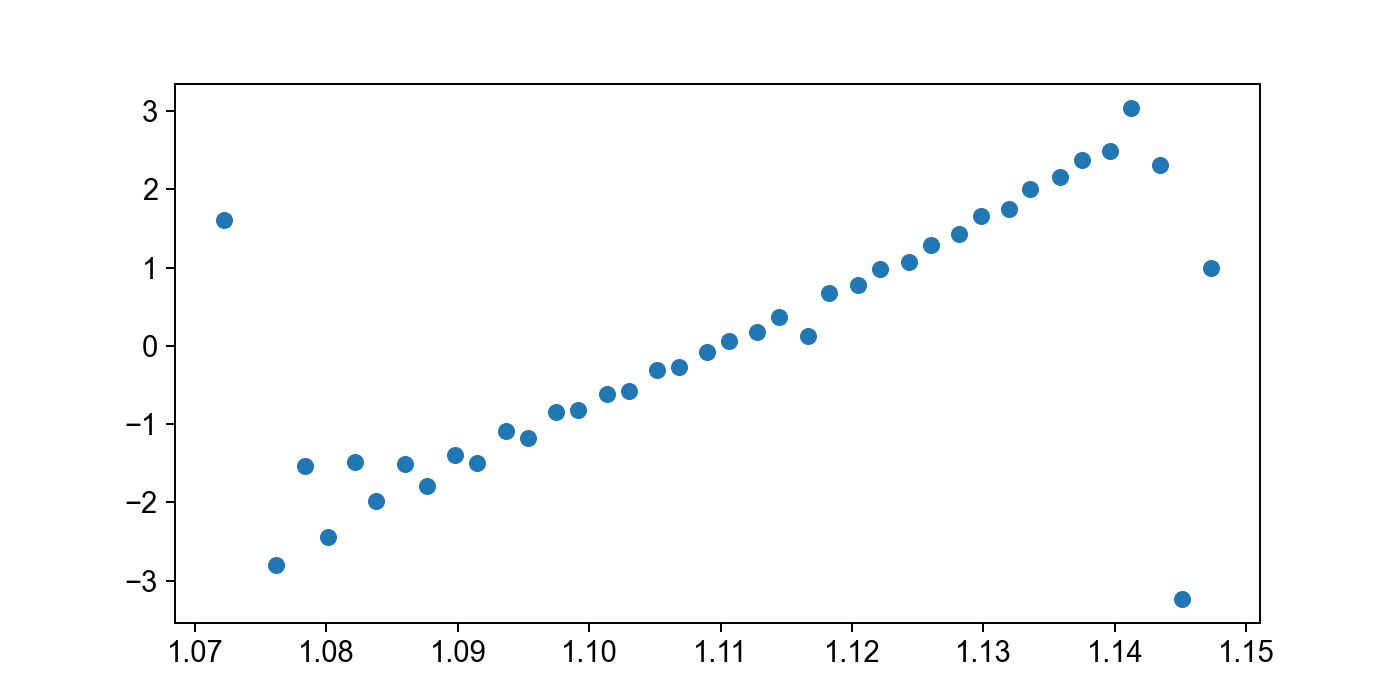

<IPython.core.display.Javascript object>


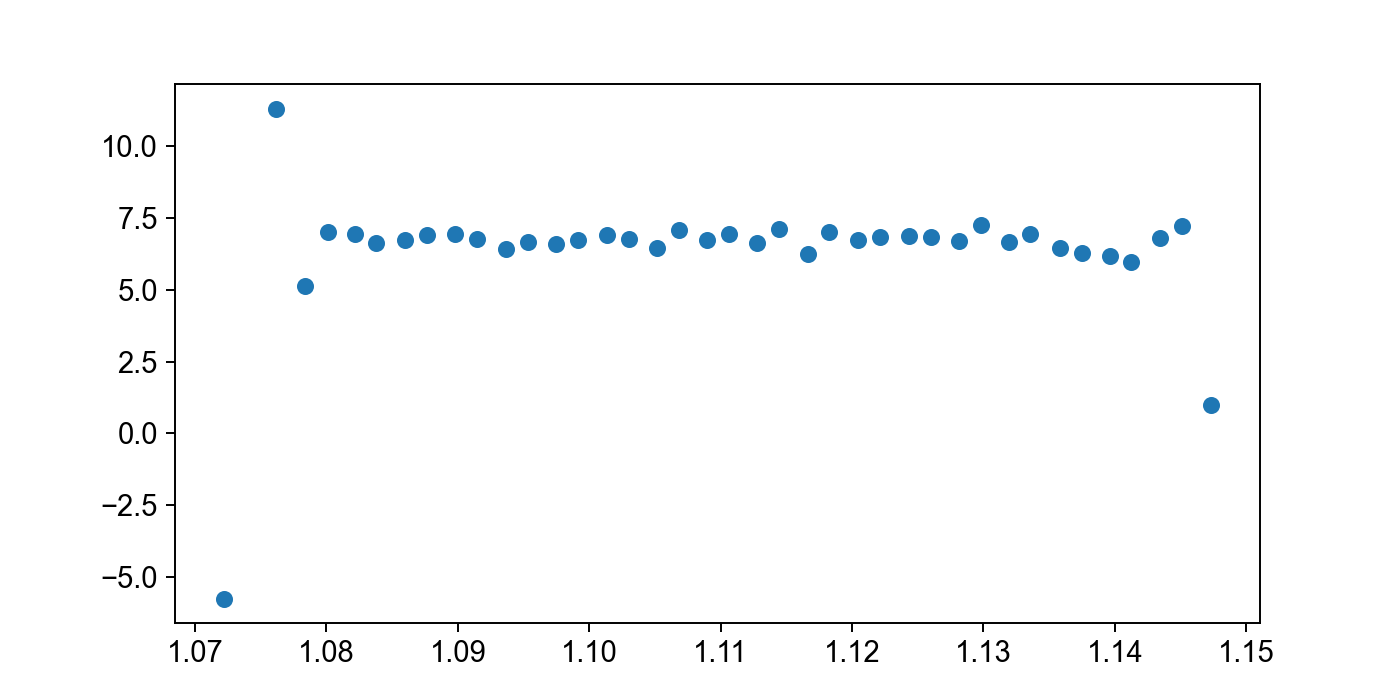

<IPython.core.display.Javascript object>


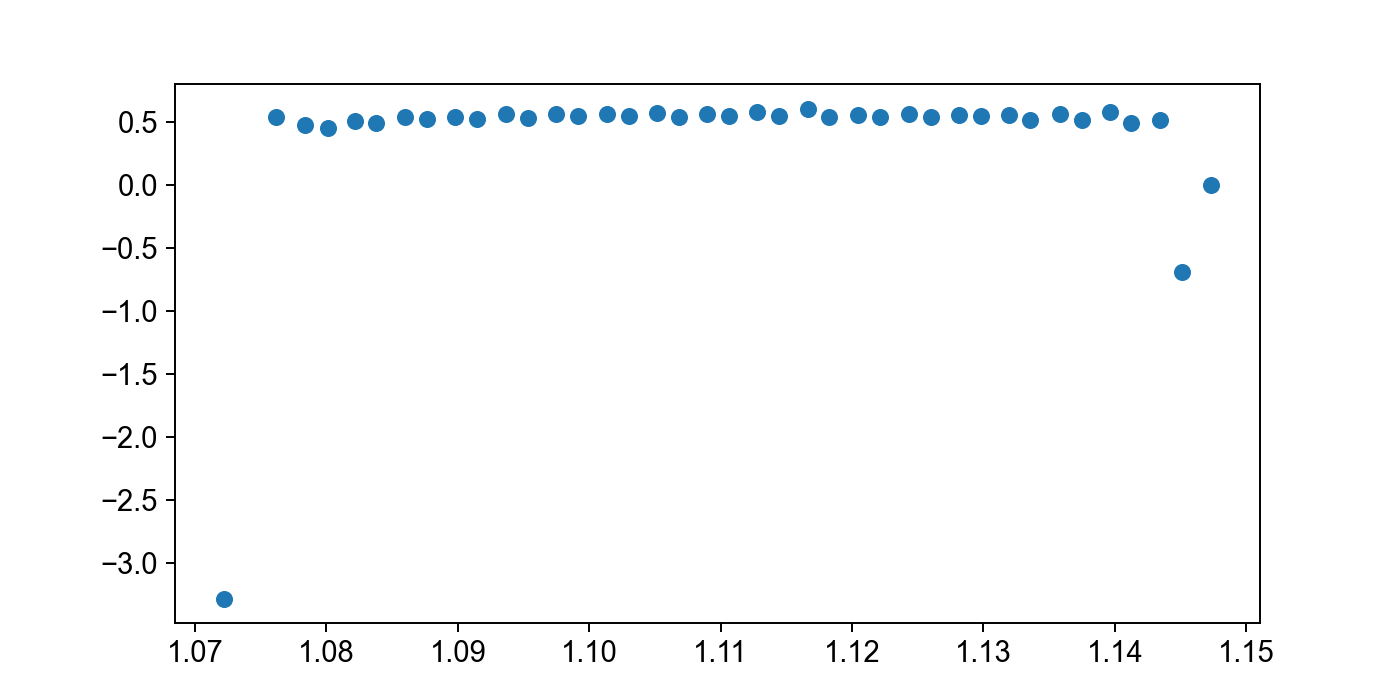

In [10]:
import matplotlib as mpl

mpl.use('TkAgg')
%matplotlib notebook 

import matplotlib.pyplot as plt 
dataset =  pickle.load(open(output_name+'_original.pkl', 'rb'))

n_points = len(dataset['bjd'])

ccf_fit_contrast = np.zeros(n_points)
ccf_fit_rv = np.zeros(n_points)
ccf_fit_fwhm = np.zeros(n_points)

for ii in range(0, n_points):
        
    parameters, covariance = curve_fit(CCF_gauss,
                                       dataset['2nd_axis'],
                                    dataset['data'][ii,:])
    ccf_fit_rv[ii] = parameters[0]
    ccf_fit_contrast[ii] = parameters[1]
    ccf_fit_fwhm[ii] = parameters[2]


phase = (dataset['bjd']-planet_dict['Tc']-planet_dict['period']/2) % planet_dict['period']


plt.figure(figsize=(8,4))
plt.scatter(phase, ccf_fit_rv)
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(phase, ccf_fit_fwhm)
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(phase, ccf_fit_contrast)
plt.show()


In [6]:
import numpy as np

import pyorbit.subroutines.constants as constants
import pyorbit.subroutines.kepler_exo as kepler_exo


import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})

import pickle #this is a very useful module indeed !
from numpy.polynomial import Polynomial

import os 
from astropy.io import fits
import sys
sys.path.insert(0, './../subroutines/')
from mu_vstar import compute_mu_vstar_grid
from rebin import *

import batman


from scipy.optimize import curve_fit



def _limb_darkening_quadratic(ld_par, mu):
    return  1 - ld_par[0]*(1. - mu) - ld_par[1]*(1. - mu)**2



def compute_output_matrix(dataset, parameter_values):

    #start filling the dictionary with relevant parameters
    planet_grid = {}
    planet_grid['n_grid'] = 21
    planet_grid['half_grid'] = int((planet_grid['n_grid'] - 1) / 2)
    planet_grid['time_step'] = 149


    """ Coordinates of the centers of each grid cell (add offset) """
    planet_grid['xx'] = np.linspace(-1.000000, 1.000000, planet_grid['n_grid'], dtype=np.double)
    planet_grid['xc'], planet_grid['yc'] = np.meshgrid(planet_grid['xx'], planet_grid['xx'], indexing='xy')
    # check the Note section of the wiki page of meshgrid
    # https://docs.scipy.org/doc/numpy/reference/generated/numpy.meshgrid.html

    """ Distance of each grid cell from the center of the stellar disk """
    planet_grid['rc'] = np.sqrt(planet_grid['xc'] ** 2 + planet_grid['yc'] ** 2)
    # Must avoid negative numbers inside the square root
    planet_grid['inside'] = planet_grid['rc'] < 1.000000
    # Must avoid negative numbers inside the square root
    planet_grid['outside'] = planet_grid['rc'] >= 1.000000


    batman_params = batman.TransitParams()

    """ Initialization with random transit parameters"""
    batman_params.t0 = parameter_values['Tc'] #time of inferior conjunction in days # here I have to set the "right one"
    batman_params.per = parameter_values['P'] #± 0.00000015 #orbital period in days
    batman_params.rp = parameter_values['R_Rs'] #± 0.00012 Rstar  #planet radius (in units of stellar radii)
    batman_params.a = parameter_values['a_Rs'] #± 0.020 #semi-major axis (in units of stellar radii)
    batman_params.inc = parameter_values['i'] #± 0.024° #orbital inclination (in degrees)
    batman_params.ecc = 0.#eccentricity
    batman_params.w = 90.#longitude of periastron (in degrees)
    batman_params.limb_dark = "quadratic" #limb darkening model
    batman_params.u = [0.416,0.287] #limb darkening coefficients [u1, u2]

    """ Setting up the limb darkening calculation"""

    batman_params.limb_dark = 'quadratic'
    # limb darkening coefficients
    batman_params.u = np.ones(2) * 0.1


    ld_par = np.zeros(2)
    ld_par[0] = parameter_values['ld_c1']
    ld_par[1] = parameter_values['ld_c2']




    lambda_rad = parameter_values['lambda'] * constants.deg2rad
    inclination_rad = parameter_values['i'] * constants.deg2rad
    omega_rad = parameter_values['omega'] * constants.deg2rad

    sin_lambda = np.sin(lambda_rad)
    cos_lambda = np.cos(lambda_rad)

    beta = (np.pi / 2.) - parameter_values['i_star'] * constants.deg2rad
    sin_beta = np.sin(beta)
    cos_beta = np.cos(beta)

    bjd = dataset['bjd']
    exptime = dataset['exptime']
    n_vals = len(bjd)


    #eclipsed_flux = np.zeros_like(bjd)
    mean_mu = np.zeros(n_vals)
    mean_vstar =  np.zeros(n_vals)

    max_oversampling = 1

    for i_obs, bjd_value in enumerate(bjd):

        n_oversampling = int(exptime[i_obs] / planet_grid['time_step'])

        """recomputing the oversampling steps to homogeneously cover the
        full integration time """
        if n_oversampling % 2 == 0:
            n_oversampling += 1

        max_oversampling = max(max_oversampling, n_oversampling)

        half_time = exptime[i_obs] / 2 / 86400.

        bjd_oversampling = np.linspace(bjd_value - half_time, bjd_value + half_time, n_oversampling, dtype=np.double)

        vstarI_sum = 0.
        I_sum = 0.
        mu_sum = 0.

        true_anomaly, orbital_distance_ratio = kepler_exo.kepler_true_anomaly_orbital_distance(
            bjd_oversampling,
            parameter_values['Tc'],
            parameter_values['P'],
            parameter_values['e'],
            parameter_values['omega'],
            parameter_values['a_Rs'])

        """ planet position during its orbital motion, in unit of stellar radius
        Following Murray & Correia 2011 https://arxiv.org/abs/1009.1738, with the argument of the ascending node set to zero.
        1) the ascending node coincide with the X axis
        2) the reference plane coincide with the plane of the sky
        Note however that the X and Y axis in Cegla et al. 2016 have opposite direction wrt those in M&C
        """

        planet_position_xp = -orbital_distance_ratio * (np.cos(omega_rad + true_anomaly))
        planet_position_yp = -orbital_distance_ratio * (np.sin(omega_rad + true_anomaly) * np.cos(inclination_rad))
        planet_position_zp = orbital_distance_ratio * (np.sin(inclination_rad) * np.sin(omega_rad + true_anomaly))

        # projected distance of the planet's center to the stellar center
        planet_position_rp = np.sqrt(planet_position_xp**2  + planet_position_yp**2)

        #print('xp', planet_position_xp)
        #print('yp', planet_position_yp)
        #print('rp', planet_position_rp)

        if np.amax(planet_position_zp) < 0.:
            continue

        if np.amin(planet_position_rp) > 1.:
            continue

        for s_obs in range(0, n_oversampling):

            xp = planet_grid['xc']*parameter_values['R_Rs'] + planet_position_xp[s_obs]
            yp = planet_grid['yc']*parameter_values['R_Rs'] + planet_position_yp[s_obs]
            r2 = xp**2 + yp**2
            sel_inside = (r2 < 1.) & (planet_grid['inside'])
            r2[~sel_inside] = 1.

            mu_grid =  np.sqrt(1. - r2)
            """ Determine the mu angle for each grid cell, as a function of radius. """

            I_grid = _limb_darkening_quadratic(ld_par, mu_grid)

            x_ortho = xp * cos_lambda - yp * sin_lambda  # orthogonal distances from the spin-axis
            y_ortho = xp * sin_lambda + yp * cos_lambda

            r2_ortho = x_ortho ** 2 + y_ortho**2
            r2_ortho[~sel_inside] = 1.
            z_ortho = np.sqrt(1.-r2_ortho)

            """ orthogonal distance from the stellar equator """
            ### Equation 7 in Cegla+2016
            yp_ortho = z_ortho * sin_beta + y_ortho * cos_beta

            """ stellar rotational velocity for a given position """
            # differential rotation is included considering a sun-like law
            rv = x_ortho * parameter_values['v_sini'] * (1. -parameter_values['alpha_rotation'] * yp_ortho ** 2)
            # Null velocity for points outside the stellar surface


            mu_sum += np.sum((mu_grid*I_grid)[sel_inside])
            vstarI_sum += np.sum((rv*I_grid)[sel_inside])
            I_sum += np.sum((I_grid)[sel_inside])

        mean_mu[i_obs] = mu_sum/I_sum
        mean_vstar[i_obs] = vstarI_sum/I_sum

    conv_rvstar =0

    rv_star = mean_vstar + conv_rvstar + parameter_values['rv_offset']
    contrast = mean_mu * parameter_values['contrast_m'] + parameter_values['contrast_q']
    sigma = (mean_mu * parameter_values['fwhm_m'] + parameter_values['fwhm_q']) / constants.sigma2FWHM

    contrast[mean_mu<0.000001] = 0.0000
    matrix = 1. - contrast[:,np.newaxis]* np.exp(-(rv_star[:,np.newaxis] - dataset['2nd_axis'])**2/(2*sigma[:,np.newaxis]**2) )
    
    return matrix, rv_star, contrast, sigma*constants.sigma2FWHM



In [7]:
folder_name='./'
mask = 'G2'
output_name = 'ccf_rmr_HARPS_G2_prefit'

dataset =  pickle.load(open(output_name+'_original.pkl', 'rb'))
#dataset =  pickle.load(open(output_name+'_improved.pkl', 'rb'))


parameter_values_fit ={'Tc': 2454279.4361834438, 'e': 0.0, 'lambda': 11.096367661461732, 'i': 85.71024066783927, 'R_Rs': 0.156672702549107, 'a_Rs': 8.723387544682755, 'P': 2.218573912321134, 'omega': 90.0, 'ld_c1': 0.8172139403033516, 'ld_c2': 9.076675915408316e-05, 'veq_star': 4.32295964804127, 'i_star': 103.00407611908372, 'v_sini': 4.212093279613805, 'rotation_period': 9.52123337602106, 'radius': 0.813203101878732, 'alpha_rotation': 0.4531157771068423, 'fwhm_m': 0.13514915082120094, 'contrast_m': 0.0726666102608258, 'rv_offset': -0.5545703362321566, 'contrast_q': 0.39087286063409926, 'fwhm_q': 6.029498230678613}

parameter_values_paper = {'Tc': 2458540.739389,
                    'e': 0.0,
                    'lambda': 0.15,
                    'i': 87.95,
                    'R_Rs': 0.0515,
                    'a_Rs': 11.14,
                    'P': 5.4435402,
                    'omega': 90.0,
                    'ld_c1': 0.416,
                    'ld_c2':  0.287,
                    'veq_star': 5.90,
                    'i_star': 90.,
                    'v_sini': 5.90,
                    'rotation_period': 12.3,
                    'radius': 0.8122833333921672,
                    'alpha_rotation': 0.0,
                    'fwhm_m': 0.00,# 0.20,
                    'contrast_m': 0.00, #0.10,
                    'rv_offset': 0.00026,
                    'contrast_q': 0.372,
                    'fwhm_q':6.50
                   }

parameter_values_fit = parameter_values_paper.copy()


parameter_values_fit = {'Tc': 2458540.739389,
                    'e': 0.0,
                    'lambda': 0.15,
                    'i': 87.95,
                    'R_Rs': 0.0515,
                    'a_Rs': 11.14,
                    'P': 5.4435402,
                    'omega': 90.0,
                    'ld_c1': 0.416,
                    'ld_c2':  0.287,
                    'veq_star': 5.90,
                    'i_star': 90.,
                    'v_sini': 5.90,
                    'rotation_period': 12.3,
                    'radius': 0.8122833333921672,
                    'alpha_rotation':  0.0,
                    'fwhm_m': 0,
                    'contrast_m': 0.0,
                    'rv_offset': 0.,
                    'contrast_q': 0.372,
                    'fwhm_q': 9.10
                   }

matrix_fit   , rv_star_fit, contrast_fit, sigma_fit  = compute_output_matrix(dataset, parameter_values_fit)
matrix_paper ,rv_star_paper, contrast_paper, sigma_paper= compute_output_matrix(dataset, parameter_values_paper)


<IPython.core.display.Javascript object>


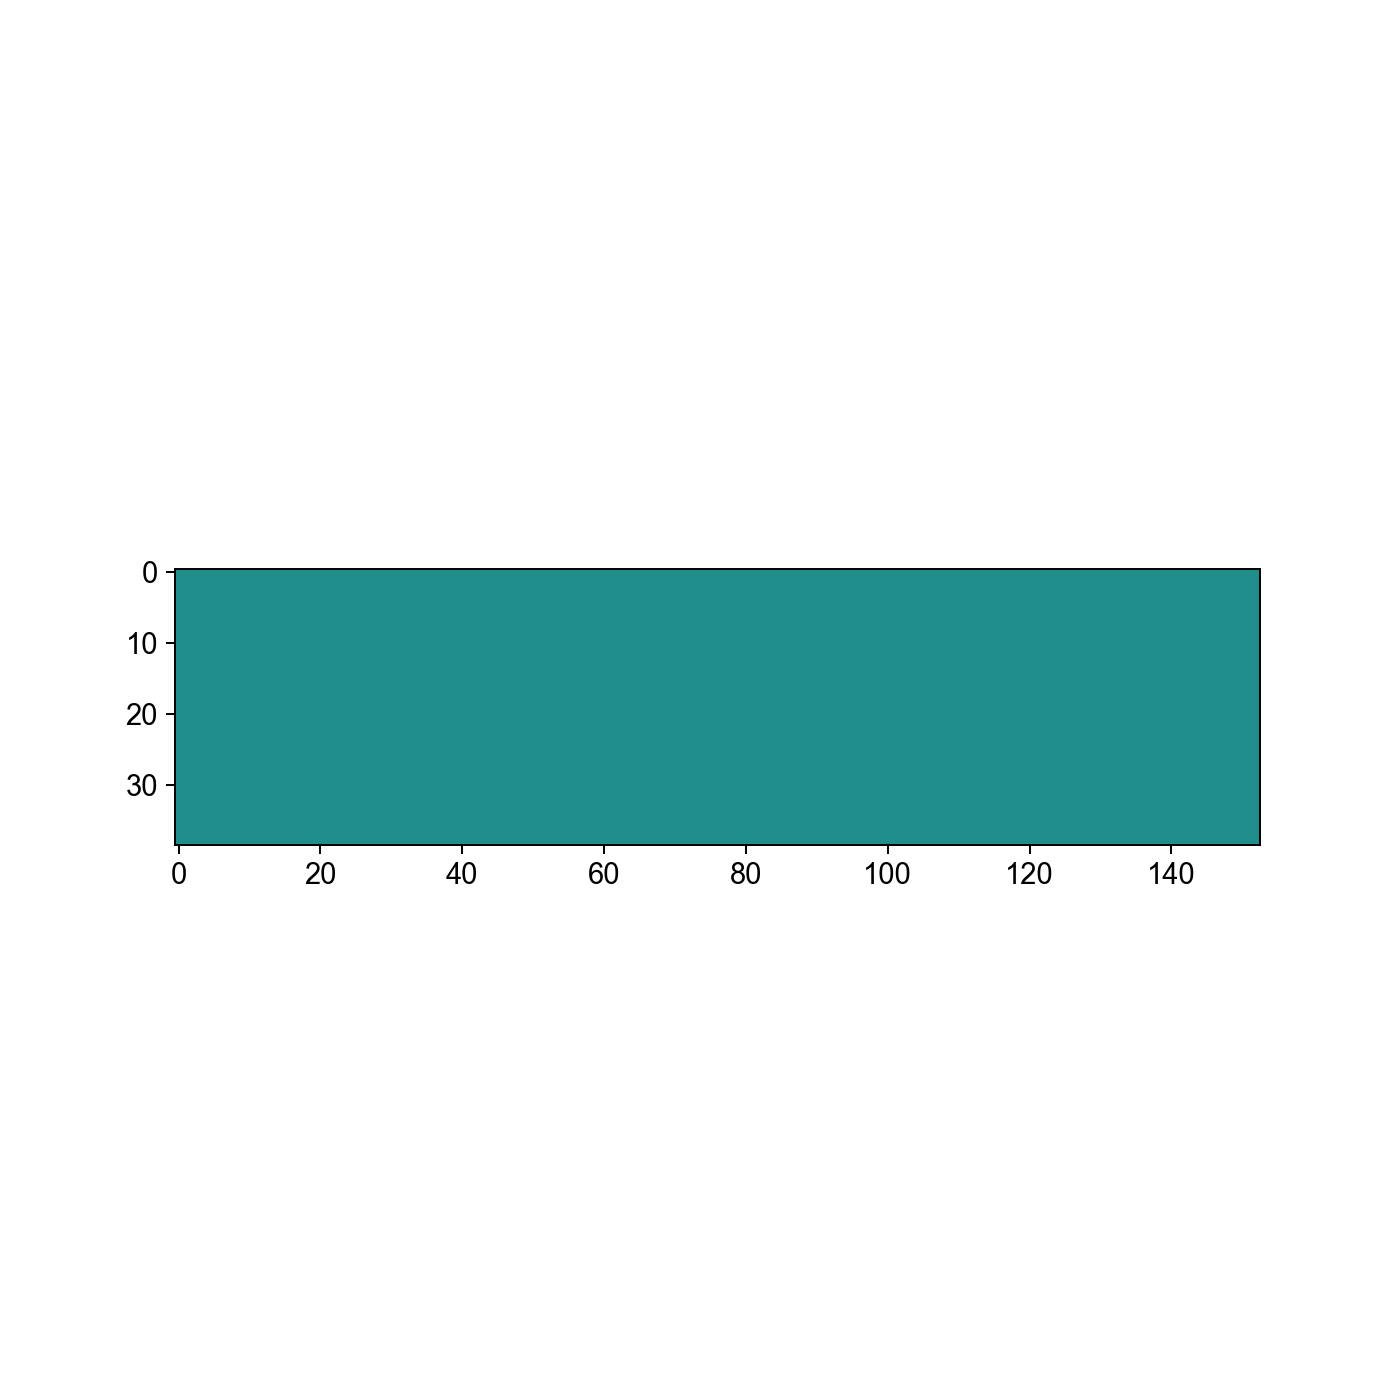

Standard deviation data-fit  0.3821956687622271


<IPython.core.display.Javascript object>


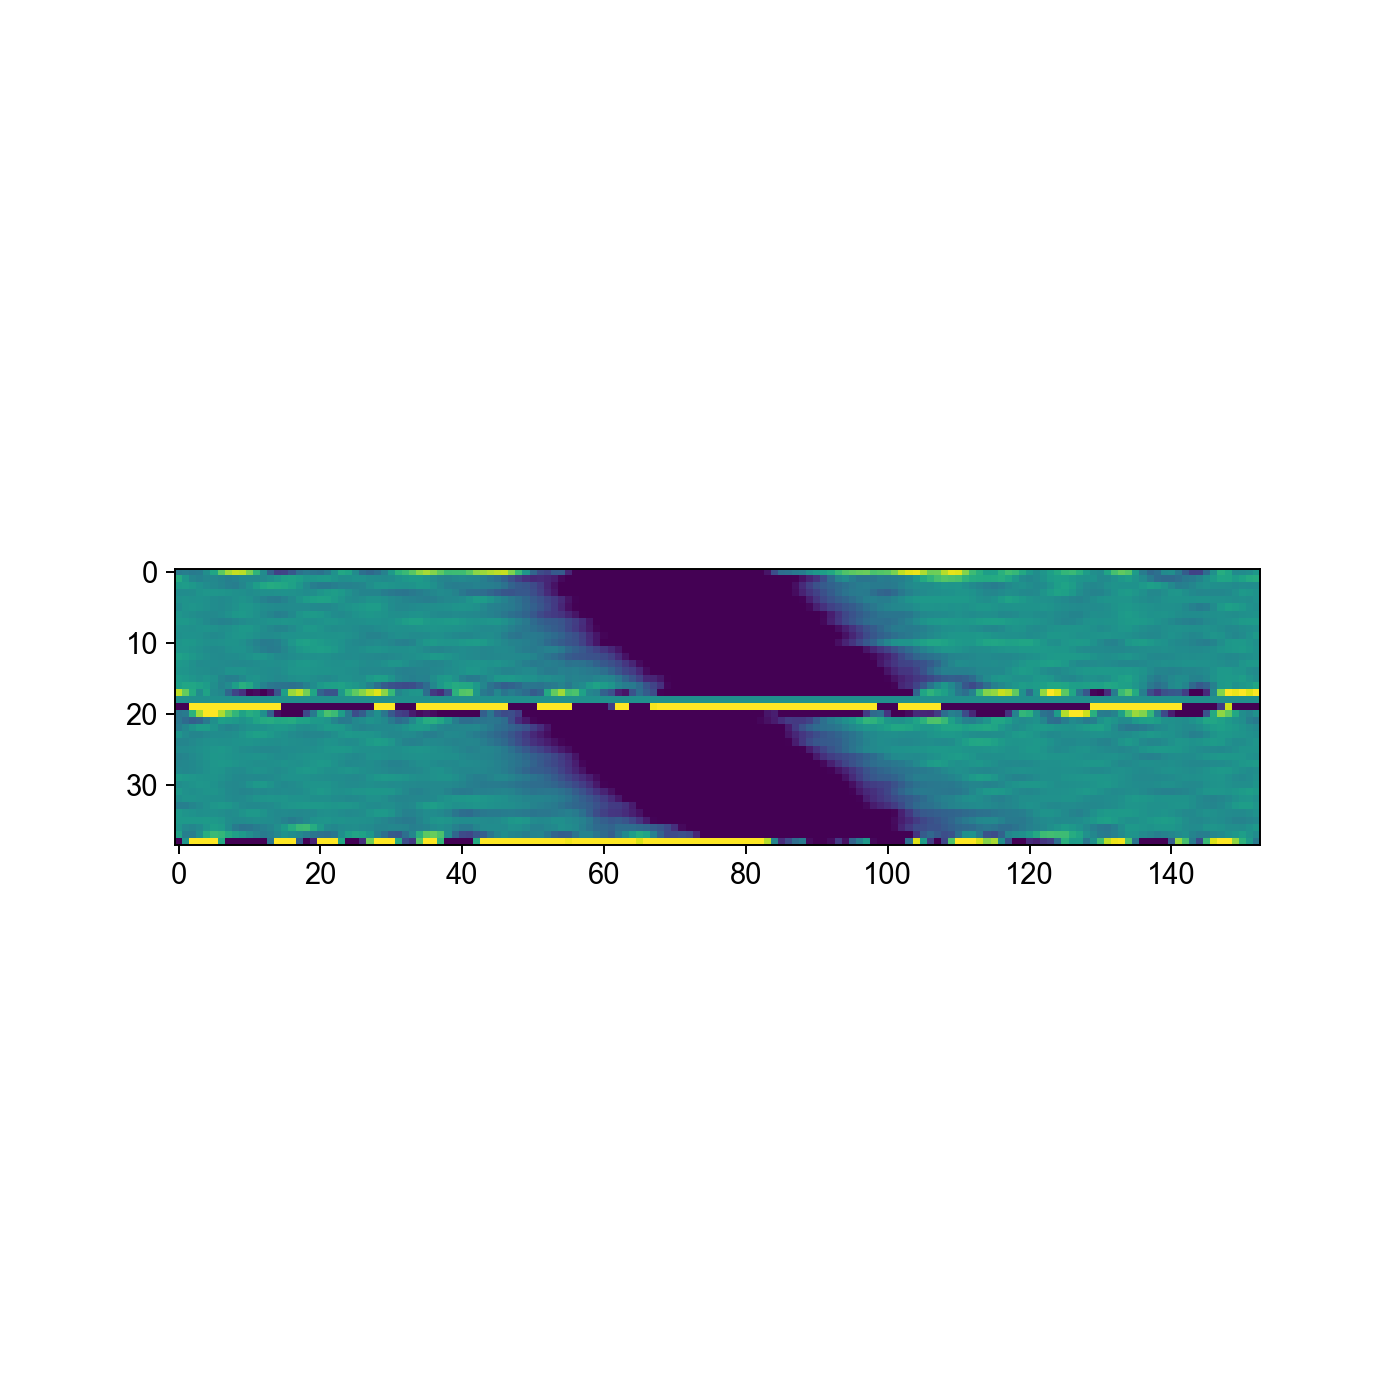

Standard deviation data-paper  0.3821956687622271


<IPython.core.display.Javascript object>


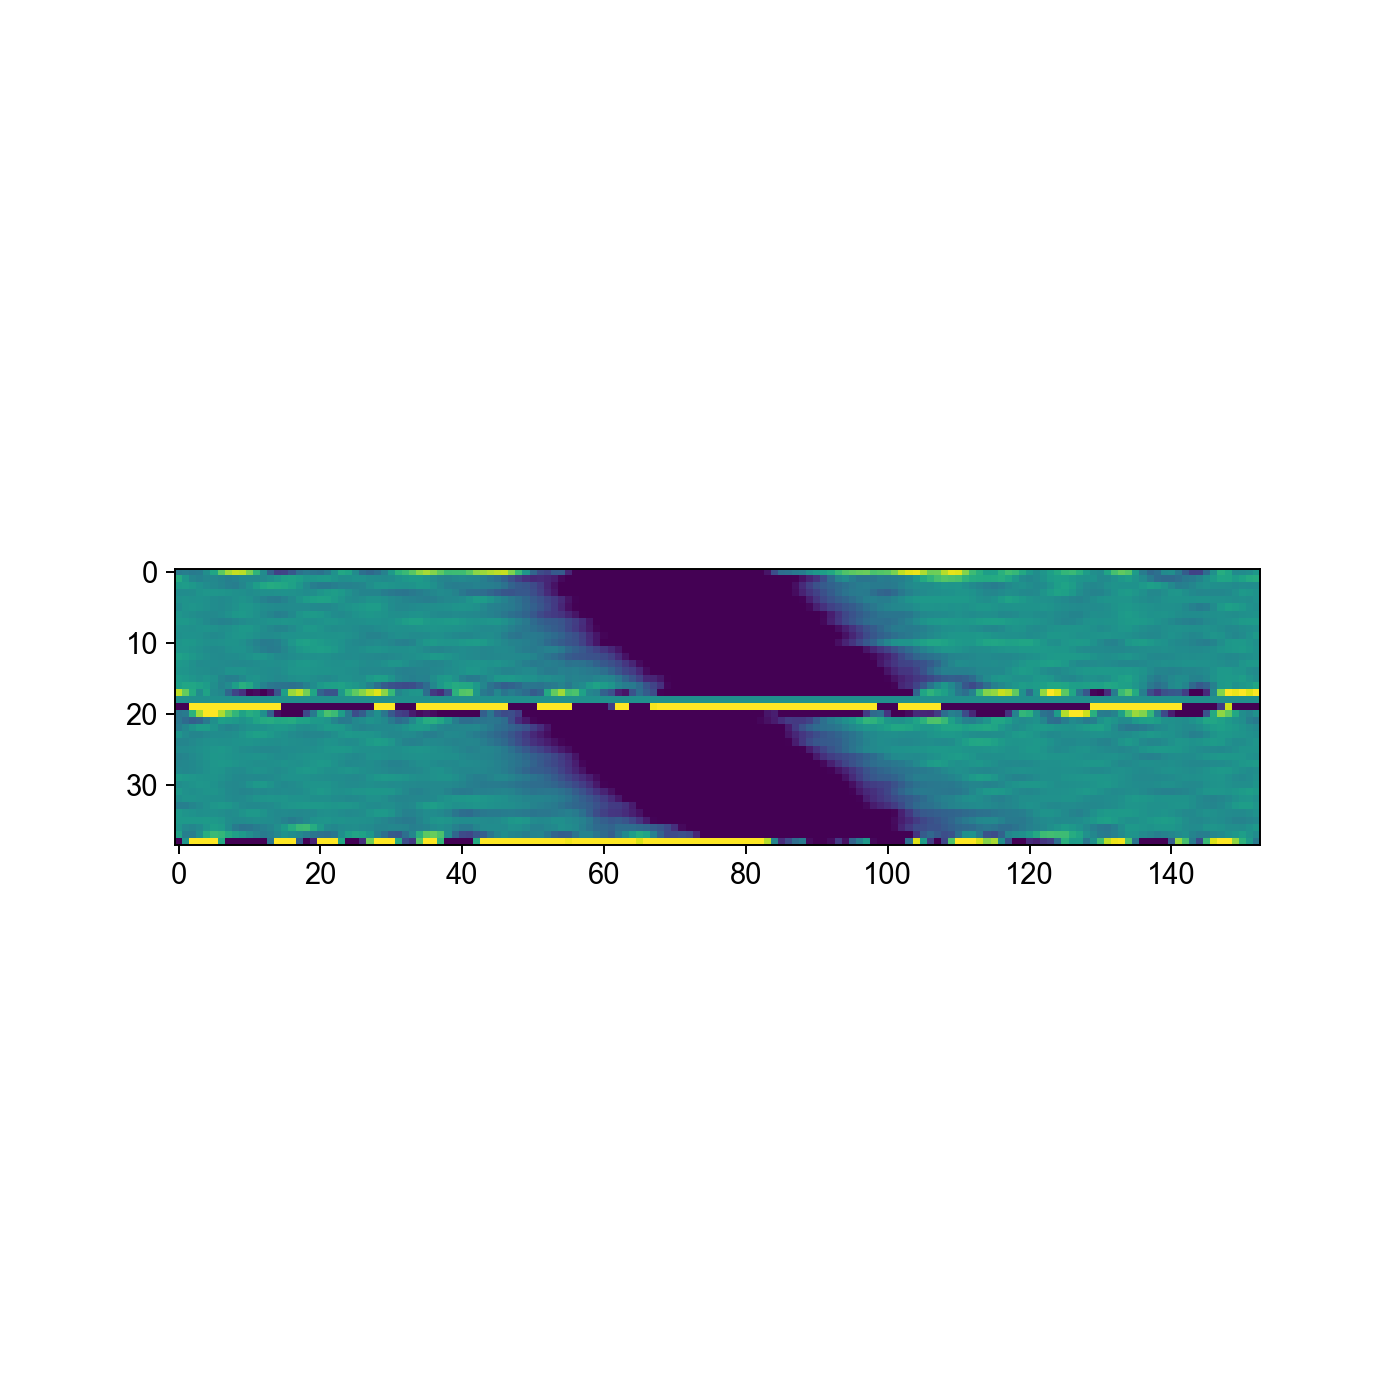

<IPython.core.display.Javascript object>


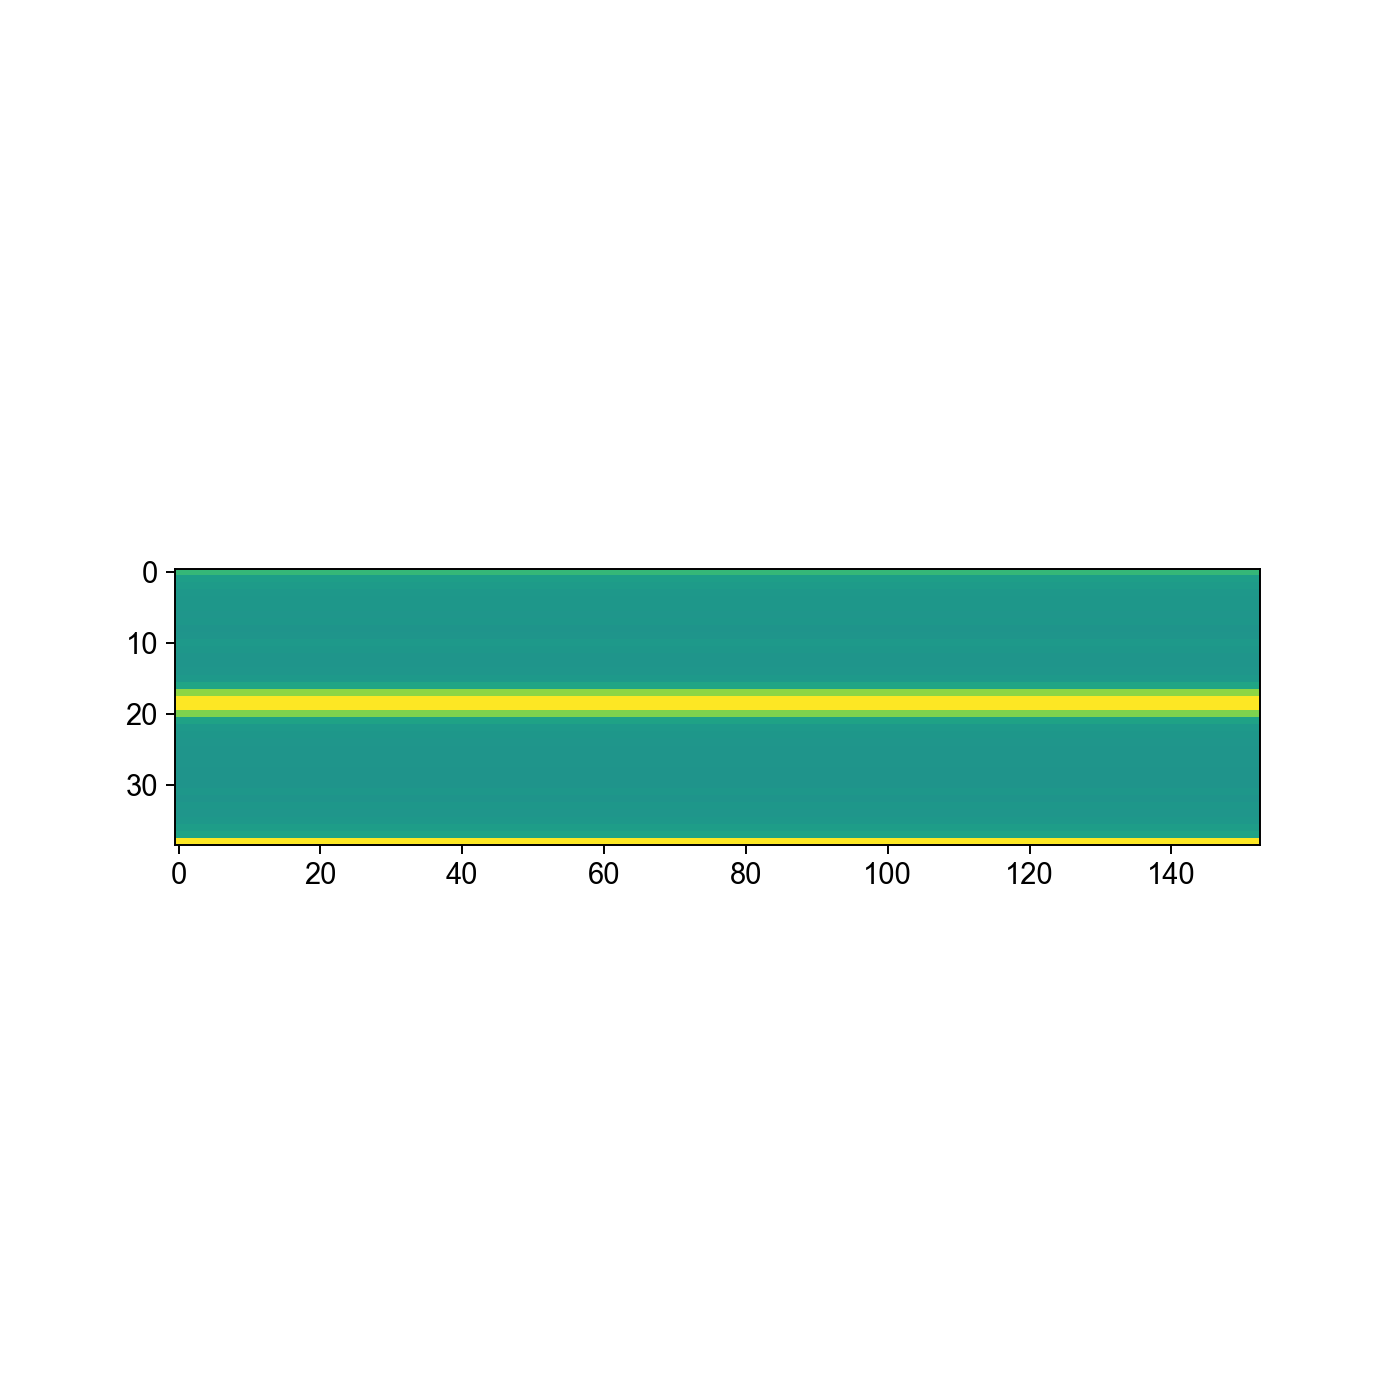

In [8]:
import matplotlib as mpl

mpl.use('TkAgg')
%matplotlib notebook 

import matplotlib.pyplot as plt 
plt.figure(figsize=(8,8))
#plt.imshow(dataset['data']-matrix_fit, vmin=-0.05, vmax = 0.05)
plt.imshow(matrix_paper-matrix_fit, vmin=-0.05, vmax = 0.05)
plt.show()

import matplotlib.pyplot as plt 

print('Standard deviation data-fit ', np.std(dataset['data']-matrix_fit))
plt.figure(figsize=(8,8))
plt.imshow(dataset['data']-matrix_fit, vmin=-0.2, vmax = 0.2)
plt.show()

import matplotlib.pyplot as plt 
print('Standard deviation data-paper ', np.std(dataset['data']-matrix_paper))
plt.figure(figsize=(8,8))
plt.imshow(dataset['data']-matrix_paper, vmin=-0.2, vmax = 0.2)
plt.show()


import matplotlib.pyplot as plt 
plt.figure(figsize=(8,8))
plt.imshow(dataset['errs'], vmin=-0.2, vmax = 0.2)
plt.show()

<IPython.core.display.Javascript object>


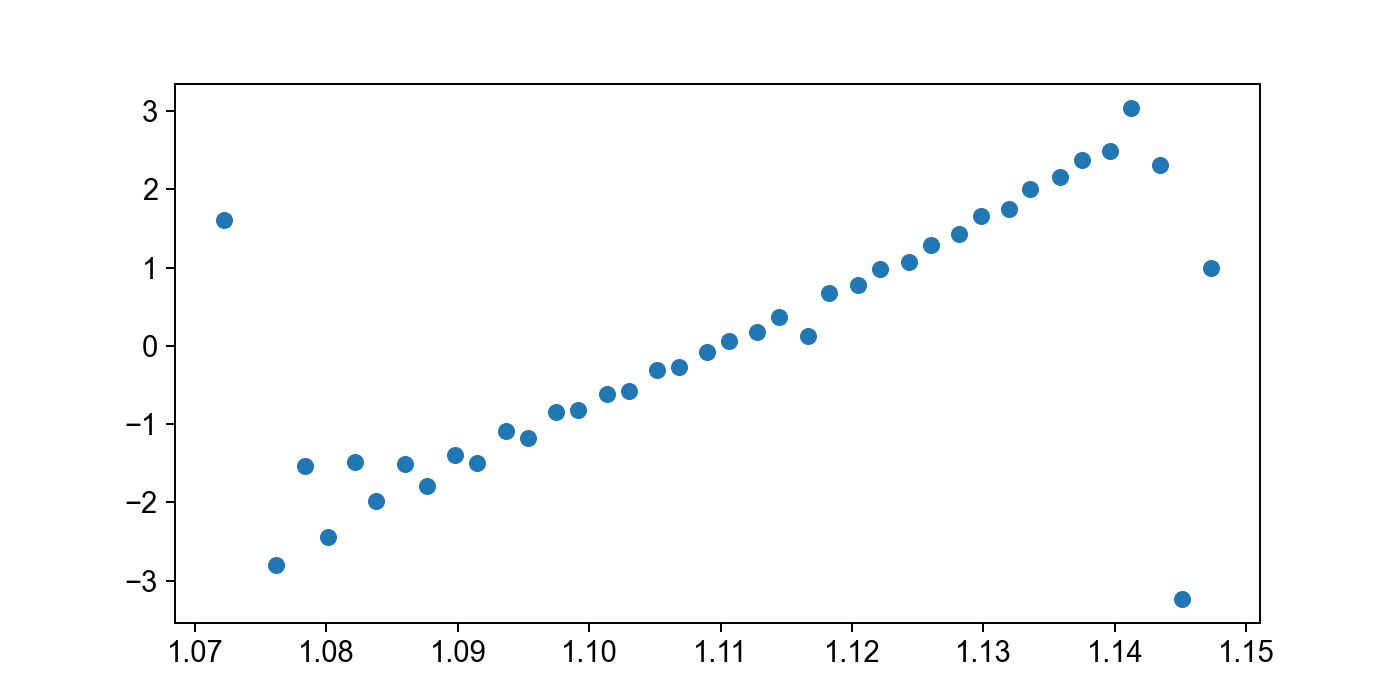

<IPython.core.display.Javascript object>


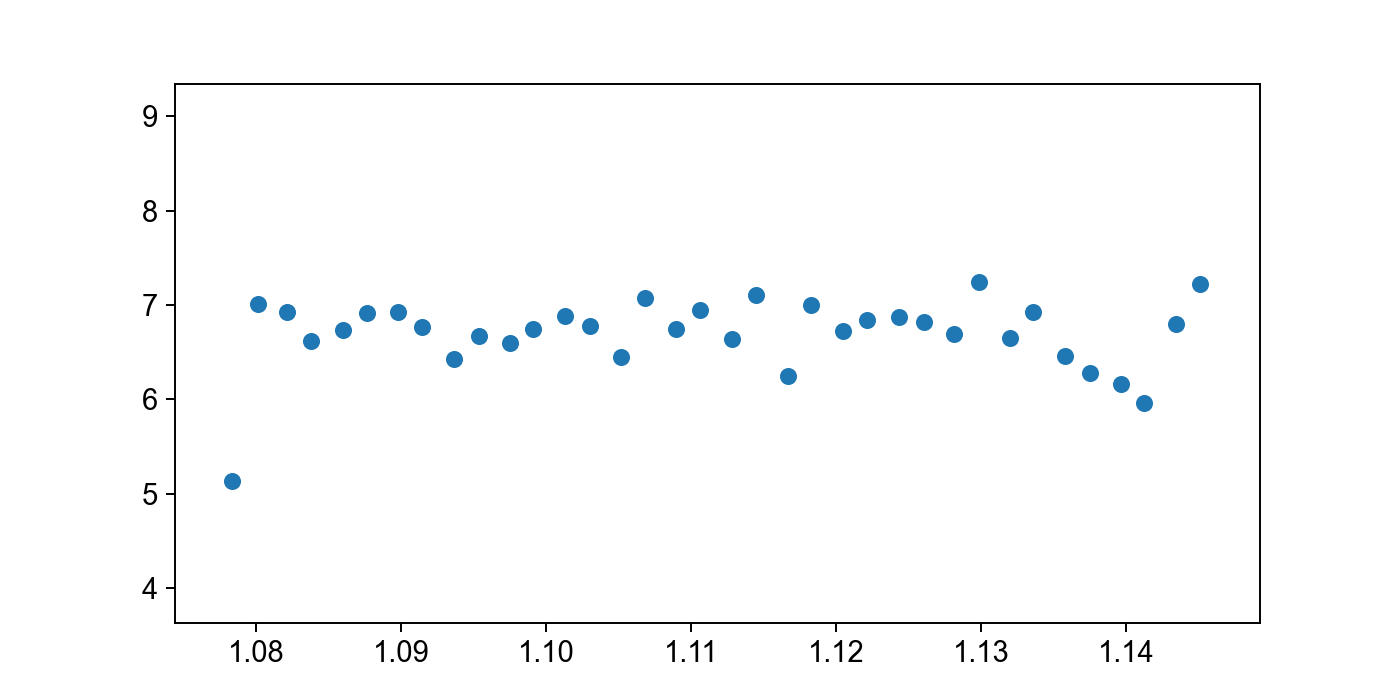

<IPython.core.display.Javascript object>


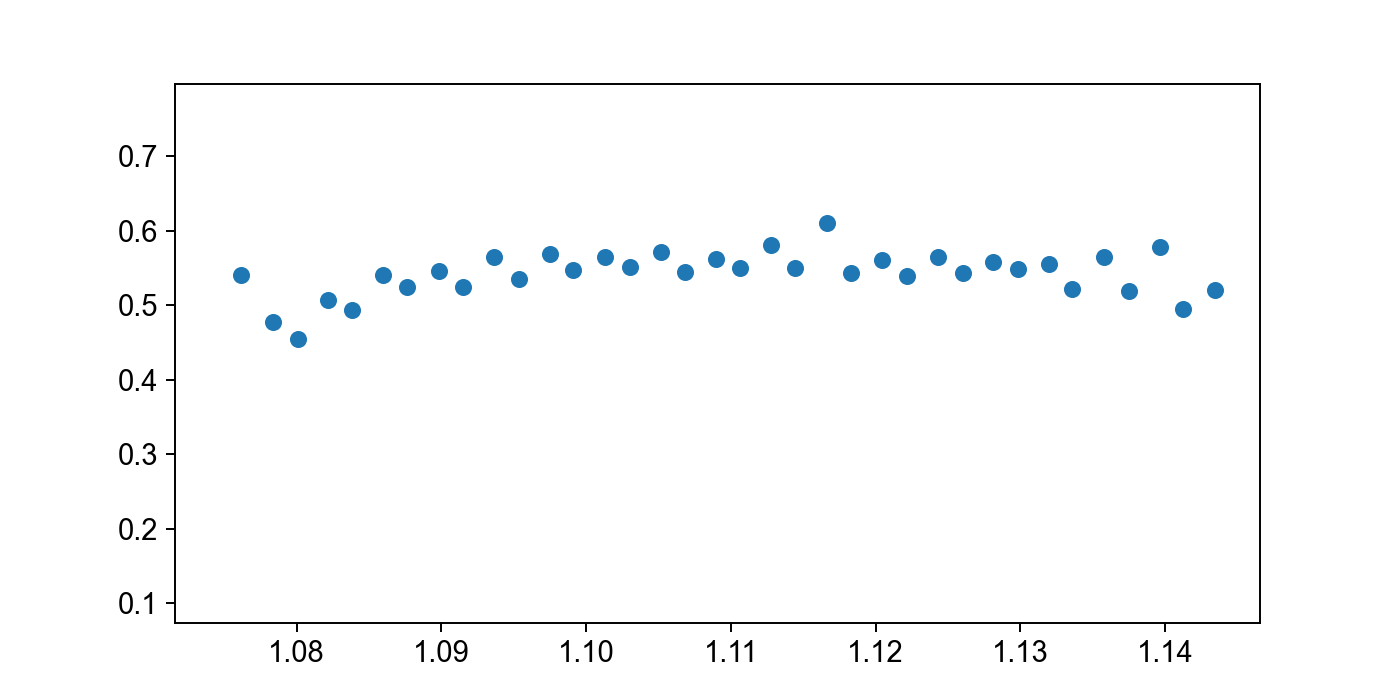

In [18]:
n_points = len(dataset['bjd'])

ccf_fit_contrast = np.zeros(n_points)
ccf_fit_rv = np.zeros(n_points)
ccf_fit_fwhm = np.zeros(n_points)

for ii in range(0, n_points):
        
    parameters, covariance = curve_fit(CCF_gauss,
                                       dataset['2nd_axis'],
                                    dataset['data'][ii,:])
    ccf_fit_rv[ii] = parameters[0]
    ccf_fit_contrast[ii] = parameters[1]
    ccf_fit_fwhm[ii] = parameters[2]


phase = (dataset['bjd']-planet_dict['Tc']-planet_dict['period']/2) % planet_dict['period']


plt.figure(figsize=(8,4))
plt.scatter(phase, ccf_fit_rv)
#plt.scatter(phase, rv_star_fit)
#plt.scatter(phase,rv_star_paper)
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(phase, ccf_fit_fwhm)
#plt.scatter(phase, sigma_fit)
#plt.scatter(phase,sigma_paper)
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(phase, ccf_fit_contrast)
#plt.scatter(phase, contrast_fit)
#plt.scatter(phase, contrast_paper)
plt.show()


#plt.show()

#plt.figure(figsize=(8,4))
#plt.scatter(phase, ccf_fit_fwhm)
#plt.show()